In [58]:
import csv
from builtins import open
def load_weights(filename: str):
    sg_wts = []
    rc_wts = []
    payoff = 0
    with open(filename, newline='') as csvfile:
        reader = csv.reader(csvfile)
        flag = True
        for row in reader:
            if flag:
                flag = False
            else:
                sg_wts.append([float(x) for x in row[4:7]])
                rc_wts.append([float(x) for x in row[7:9]])
                if len(row) == 10:
                    payoff = float(row[9])
    return sg_wts, rc_wts, payoff

In [59]:
import numpy as np

# deduce the strategy of a single state
def deduce_strategy(sgw: list):
    a, b, c = sgw
    if (a >= 0.1 and b >= 0.1):
        return "0/1"
    elif (b >= 0.1 and c >= 0.1):
        return "1/null"
    elif (c >= 0.1 and a >= 0.1):
        return "0/null"
    return str(np.argmax(sgw))


def deduce_reci_action(acw: np.array):
    a = np.argmax(acw[:, 0])
    b = np.argmax(acw[:, 1])
    return (a, b)

In [60]:
def get_label(strat: list) -> list:
    lbls = []
    visited = set()
    seen = set()
    if strat[0] == "2":
        lbls.append("left edge")
    for i in range(1, len(strat)):
        # if we have "left edge" uncertainty, ignore
        if strat[i-1] == "2":
            continue

        # if we've been here before, skip
        # I'm only including this because Python is weird
        # about incrementing the iterator in a for loop.
        if i in visited:
            continue

        visited.add(i)
        choice = strat[i]

        if choice not in ["0", "1", "2"]:
            continue

        # if our current choice is the null signal, determine how large
        # the region is and then increment i to the end of the region.
        if choice == "2":
            j = i
            while j < len(strat) and strat[j] == "2":
                visited.add(j)
                j += 1
            
            if j == len(strat):
                # if we fall off the end, this is "right edge" uncertainty and we're done.
                lbls.append("right edge")
                break
            else:
                lbls.append(f"Vague between {i} and {j}")
                i = j # does this really work? - no

        # if the next choice in strategy is not the same as here,
        # we've reached the end of a contiguous region. 
        # if we've seen this type of region before, there is non-contiguity.
        if choice in seen:
            lbls.append(f"Non-contiguous {choice}")
        elif i+1 != len(strat) and choice != strat[i+1]:
            seen.add(choice)
        
            
    return lbls

In [61]:
def game_report(filename: str):
    signal_weights, reci_weights, payoff = load_weights(filename)

    strategy = []
    for i in range(len(signal_weights)):
        strategy.append(deduce_strategy(signal_weights[i]))

    reciever_strategy = deduce_reci_action(np.array(reci_weights))

    null_used = "2" in strategy
    mixed_signals = "mixed" in strategy
    label = get_label(strategy)
    both_signals = "0" in strategy

    print(" | ".join(strategy))
    print(reciever_strategy)
    print(f"Null used: {null_used}")
    print(f"Mixed signaling: {mixed_signals}")
    print(f"Labels: {', '.join(label)}")

In [62]:
from os import listdir
def get_stats_by_folder(folder: str):
    files = listdir(folder)
    files = [x for x in files if x[-3:] == "csv"]
    stats = {
        "vagueness": set(),
        "both_signals": set(),
        "one_signal": set(),
        "multiple_vague_regions": set(),
        "reciever_agreement": set(),
        "non_contiguity": set(),
        "no_signaling": set(),
        "edges": set(),
        "average_payoff": 0
    }
    payoff_avg = 0
    for fi in files:
        sig_weights, reci_weights, payoff = load_weights(folder + fi)
        payoff_avg += payoff
        sender_strategy = []
        for i in range(len(sig_weights)):
            sender_strategy.append(deduce_strategy(sig_weights[i]))

        reciever_strategy = deduce_reci_action(np.array(reci_weights))
        labels = get_label(sender_strategy)
        vg_count = 0
        for label in labels:
            if label.startswith("Vague"):
                vg_count += 1
            elif label.startswith("Non-contiguous"):
                stats["non_contiguity"].add(fi)
            elif label.startswith("left") or label.startswith("right"):
                stats["edges"].add(fi)

        if vg_count > 1:
            stats["vagueness"].add(fi)
            stats["multiple_vague_regions"].add(fi)
        elif vg_count > 0:
            stats["vagueness"].add(fi)

        if "0" in sender_strategy and "1" in sender_strategy:
            stats["both_signals"].add(fi)
        elif "0" in sender_strategy or "1" in sender_strategy:
            stats["one_signal"].add(fi)
        else:
            stats["no_signaling"].add(fi)

        if reciever_strategy[0] == reciever_strategy[1]:
            stats["reciever_agreement"].add(fi)
    if payoff_avg != 0:
        stats["average_payoff"] = payoff_avg / len(files)
    return stats

In [63]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

def display_game(filename: str):
    image = np.asarray(Image.open(filename))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [64]:
def print_stats(stats_dict: dict):
    print(f"Vagueness: {len(stats_dict['vagueness'])}")
    print(f"Both Signals: {len(stats_dict['both_signals'])}")
    print(f"One Signal: {len(stats_dict['one_signal'])}")
    print(f"No Signals: {len(stats_dict['no_signaling'])}")
    print(f"Reciever Agreement: {len(stats_dict['reciever_agreement'])}")
    print(f"Non-contiguity: {len(stats_dict['non_contiguity'])}")
    print(f"Edges: {len(stats_dict['edges'])}")
    print(f"Average payoff: {stats_dict['average_payoff']}")

# Small Batch

## Without reciever stimgen

### d = 0.3
reward = 1 - 0.3x

In [65]:
directory = "./simulations/20_2_20/final_results/small batch/no_reciever_stimgen/30/"
stats_a = get_stats_by_folder(directory)

In [66]:
print_stats(stats_a)

Vagueness: 3
Both Signals: 58
One Signal: 42
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 99
Average payoff: 0


In [67]:
print(repr(stats_a["vagueness"]))

{'null_usage_1_0.3_44.csv', 'null_usage_1_0.3_68.csv', 'null_usage_1_0.3_97.csv'}


### d = 0.25
reward = 1 - 0.25x

In [68]:
directory = "./simulations/20_2_20/final_results/small batch/no_reciever_stimgen/25/"
stats_b = get_stats_by_folder(directory)

In [69]:
print_stats(stats_b)

Vagueness: 5
Both Signals: 91
One Signal: 9
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 100
Average payoff: 0


In [70]:
print(repr(stats_b["vagueness"]))

{'null_usage_1_0.25_49.csv', 'null_usage_1_0.25_8.csv', 'null_usage_1_0.25_64.csv', 'null_usage_1_0.25_75.csv', 'null_usage_1_0.25_35.csv'}


### d = 0.2
reward = 1 - 0.2x

In [71]:
directory = "./simulations/20_2_20/final_results/small batch/no_reciever_stimgen/20/"
stats_c = get_stats_by_folder(directory)

In [72]:
print_stats(stats_c)

Vagueness: 2
Both Signals: 98
One Signal: 2
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 94
Average payoff: 0


In [73]:
print(repr(stats_c["vagueness"]))

{'null_usage_1_0.2_87.csv', 'null_usage_1_0.2_0.csv'}


null_usage_1_0.2_87.csv
1 | 1 | 1 | 1 | 1 | 1 | 1 | 2 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0
(np.int64(14), np.int64(1))
Null used: True
Mixed signaling: False
Labels: Vague between 7 and 9


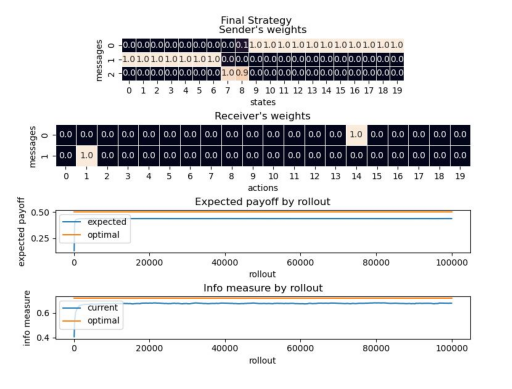

In [74]:
target_game = list(stats_c['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
display_game(directory + "(1, 0.2)_null_100000_87.jpg")

## Receiver Stimgen

### d = 0.3

In [75]:
directory = "./simulations/20_2_20/final_results/small batch/reciever_stimgen/30/"
stats_ba = get_stats_by_folder(directory)

In [76]:
print_stats(stats_ba)

Vagueness: 3
Both Signals: 50
One Signal: 50
No Signals: 0
Reciever Agreement: 1
Non-contiguity: 0
Edges: 99
Average payoff: 0


In [77]:
print(repr(stats_ba["vagueness"]))

{'null_usage_1_0.3_55.csv', 'null_usage_1_0.3_43.csv', 'null_usage_1_0.3_89.csv'}


null_usage_1_0.3_55.csv
0 | 0 | 0 | 0 | 0 | 0 | 0 | 2 | 2 | 2 | 2 | 2 | 2 | 1 | 1 | 1 | 1 | 1 | 1 | 1
(np.int64(3), np.int64(16))
Null used: True
Mixed signaling: False
Labels: Vague between 7 and 13


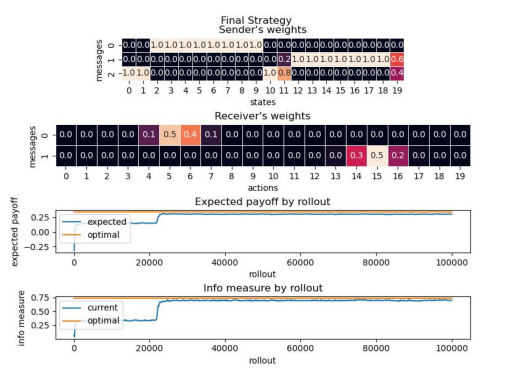

In [78]:
target_game = list(stats_ba['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
# I had to hardcode this, no brain cycles left
display_game(directory + "(1, 0.3)_null_100000_43.jpg")

### d = 0.25
reward = 1 - 0.25x

In [79]:
directory = "./simulations/20_2_20/final_results/small batch/reciever_stimgen/25/"
stats_bb = get_stats_by_folder(directory)

In [80]:
print_stats(stats_bb)

Vagueness: 3
Both Signals: 87
One Signal: 13
No Signals: 0
Reciever Agreement: 1
Non-contiguity: 0
Edges: 98
Average payoff: 0


In [81]:
print(repr(stats_bb["vagueness"]))

{'null_usage_1_0.25_62.csv', 'null_usage_1_0.25_18.csv', 'null_usage_1_0.25_55.csv'}


### d = 0.2
reward = 1 - 0.2x

In [82]:
directory = "./simulations/20_2_20/final_results/small batch/reciever_stimgen/20/"
stats_bc = get_stats_by_folder(directory)

In [83]:
print_stats(stats_bc)

Vagueness: 3
Both Signals: 97
One Signal: 3
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 0
Edges: 87
Average payoff: 0


In [84]:
print(repr(stats_bc["vagueness"]))

{'null_usage_1_0.2_83.csv', 'null_usage_1_0.2_95.csv', 'null_usage_1_0.2_89.csv'}


null_usage_1_0.2_83.csv
1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0
(np.int64(16), np.int64(4))
Null used: True
Mixed signaling: False
Labels: Vague between 10 and 11


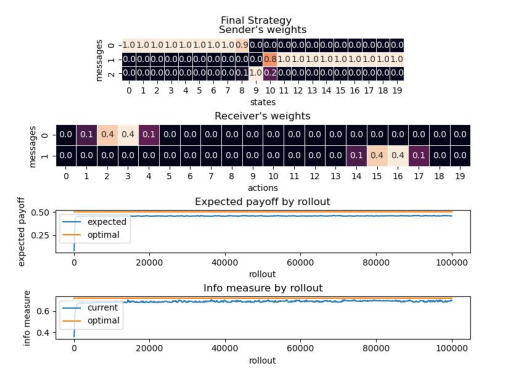

In [85]:
target_game = list(stats_bc['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
# I had to hardcode this, no brain cycles left
display_game(directory + "(1, 0.2)_null_100000_89.jpg")

# Large Batch

## Without reciever stimgen

### d = 0.3
reward = 1 - 0.3x

In [86]:
directory = "./simulations/20_2_20/final_results/large batch/no_reciever_stimgen/30/"
stats_a = get_stats_by_folder(directory)

In [87]:
print_stats(stats_a)

Vagueness: 18
Both Signals: 677
One Signal: 323
No Signals: 0
Reciever Agreement: 12
Non-contiguity: 0
Edges: 998
Average payoff: 0.2618453291875157


In [88]:
print(repr(stats_a["vagueness"]))

{'null_usage_1_0.3_127.csv', 'null_usage_1_0.3_850.csv', 'null_usage_1_0.3_841.csv', 'null_usage_1_0.3_977.csv', 'null_usage_1_0.3_151.csv', 'null_usage_1_0.3_119.csv', 'null_usage_1_0.3_235.csv', 'null_usage_1_0.3_26.csv', 'null_usage_1_0.3_397.csv', 'null_usage_1_0.3_97.csv', 'null_usage_1_0.3_446.csv', 'null_usage_1_0.3_881.csv', 'null_usage_1_0.3_178.csv', 'null_usage_1_0.3_297.csv', 'null_usage_1_0.3_975.csv', 'null_usage_1_0.3_690.csv', 'null_usage_1_0.3_488.csv', 'null_usage_1_0.3_753.csv'}


### d = 0.25
reward = 1 - 0.25x

In [89]:
directory = "./simulations/20_2_20/final_results/large batch/no_reciever_stimgen/25/"
stats_b = get_stats_by_folder(directory)

In [90]:
print_stats(stats_b)

Vagueness: 52
Both Signals: 914
One Signal: 86
No Signals: 0
Reciever Agreement: 6
Non-contiguity: 0
Edges: 992
Average payoff: 0.3517785038031827


In [91]:
print(repr(stats_b["vagueness"]))

{'null_usage_1_0.25_49.csv', 'null_usage_1_0.25_280.csv', 'null_usage_1_0.25_881.csv', 'null_usage_1_0.25_206.csv', 'null_usage_1_0.25_78.csv', 'null_usage_1_0.25_586.csv', 'null_usage_1_0.25_198.csv', 'null_usage_1_0.25_748.csv', 'null_usage_1_0.25_110.csv', 'null_usage_1_0.25_566.csv', 'null_usage_1_0.25_906.csv', 'null_usage_1_0.25_908.csv', 'null_usage_1_0.25_884.csv', 'null_usage_1_0.25_747.csv', 'null_usage_1_0.25_650.csv', 'null_usage_1_0.25_470.csv', 'null_usage_1_0.25_847.csv', 'null_usage_1_0.25_658.csv', 'null_usage_1_0.25_786.csv', 'null_usage_1_0.25_340.csv', 'null_usage_1_0.25_9.csv', 'null_usage_1_0.25_37.csv', 'null_usage_1_0.25_167.csv', 'null_usage_1_0.25_533.csv', 'null_usage_1_0.25_977.csv', 'null_usage_1_0.25_967.csv', 'null_usage_1_0.25_829.csv', 'null_usage_1_0.25_478.csv', 'null_usage_1_0.25_573.csv', 'null_usage_1_0.25_271.csv', 'null_usage_1_0.25_775.csv', 'null_usage_1_0.25_540.csv', 'null_usage_1_0.25_403.csv', 'null_usage_1_0.25_697.csv', 'null_usage_1_0.25

### d = 0.2
reward = 1 - 0.2x

In [92]:
directory = "./simulations/20_2_20/final_results/large batch/no_reciever_stimgen/20/"
stats_c = get_stats_by_folder(directory)

In [93]:
print_stats(stats_c)

Vagueness: 27
Both Signals: 987
One Signal: 13
No Signals: 0
Reciever Agreement: 9
Non-contiguity: 1
Edges: 930
Average payoff: 0.43813549013852804


In [94]:
print(repr(stats_c["vagueness"]))

{'null_usage_1_0.2_483.csv', 'null_usage_1_0.2_765.csv', 'null_usage_1_0.2_331.csv', 'null_usage_1_0.2_981.csv', 'null_usage_1_0.2_677.csv', 'null_usage_1_0.2_40.csv', 'null_usage_1_0.2_85.csv', 'null_usage_1_0.2_823.csv', 'null_usage_1_0.2_876.csv', 'null_usage_1_0.2_443.csv', 'null_usage_1_0.2_739.csv', 'null_usage_1_0.2_561.csv', 'null_usage_1_0.2_124.csv', 'null_usage_1_0.2_65.csv', 'null_usage_1_0.2_786.csv', 'null_usage_1_0.2_191.csv', 'null_usage_1_0.2_274.csv', 'null_usage_1_0.2_922.csv', 'null_usage_1_0.2_583.csv', 'null_usage_1_0.2_746.csv', 'null_usage_1_0.2_337.csv', 'null_usage_1_0.2_388.csv', 'null_usage_1_0.2_933.csv', 'null_usage_1_0.2_856.csv', 'null_usage_1_0.2_882.csv', 'null_usage_1_0.2_937.csv', 'null_usage_1_0.2_321.csv'}


null_usage_1_0.2_483.csv
0 | 0 | 0 | 0 | 0 | 0 | 0 | 2 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 2
(np.int64(1), np.int64(13))
Null used: True
Mixed signaling: False
Labels: Vague between 7 and 8, right edge


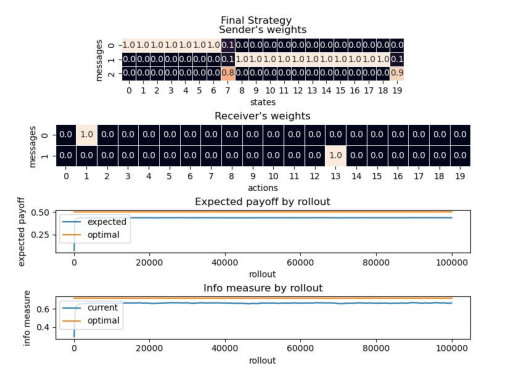

In [95]:
target_game = list(stats_c['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
display_game(directory + "(1, 0.2)_null_100000_483.jpg")

## Receiver Stimgen

### d = 0.3

In [96]:
directory = "./simulations/20_2_20/final_results/large batch/reciever_stimgen/30/"
stats_ba = get_stats_by_folder(directory)

In [97]:
print_stats(stats_ba)

Vagueness: 35
Both Signals: 549
One Signal: 447
No Signals: 4
Reciever Agreement: 13
Non-contiguity: 0
Edges: 998
Average payoff: 0.23444080010845725


In [98]:
print(repr(stats_ba["vagueness"]))

{'null_usage_1_0.3_387.csv', 'null_usage_1_0.3_331.csv', 'null_usage_1_0.3_494.csv', 'null_usage_1_0.3_784.csv', 'null_usage_1_0.3_464.csv', 'null_usage_1_0.3_562.csv', 'null_usage_1_0.3_777.csv', 'null_usage_1_0.3_236.csv', 'null_usage_1_0.3_545.csv', 'null_usage_1_0.3_13.csv', 'null_usage_1_0.3_189.csv', 'null_usage_1_0.3_604.csv', 'null_usage_1_0.3_164.csv', 'null_usage_1_0.3_695.csv', 'null_usage_1_0.3_698.csv', 'null_usage_1_0.3_858.csv', 'null_usage_1_0.3_690.csv', 'null_usage_1_0.3_706.csv', 'null_usage_1_0.3_532.csv', 'null_usage_1_0.3_87.csv', 'null_usage_1_0.3_349.csv', 'null_usage_1_0.3_895.csv', 'null_usage_1_0.3_277.csv', 'null_usage_1_0.3_820.csv', 'null_usage_1_0.3_485.csv', 'null_usage_1_0.3_615.csv', 'null_usage_1_0.3_395.csv', 'null_usage_1_0.3_153.csv', 'null_usage_1_0.3_401.csv', 'null_usage_1_0.3_758.csv', 'null_usage_1_0.3_19.csv', 'null_usage_1_0.3_132.csv', 'null_usage_1_0.3_845.csv', 'null_usage_1_0.3_450.csv', 'null_usage_1_0.3_818.csv'}


null_usage_1_0.3_387.csv
1/null | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1/null | 2 | 2 | 0/null | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0/null
(np.int64(15), np.int64(4))
Null used: True
Mixed signaling: False
Labels: Vague between 9 and 11


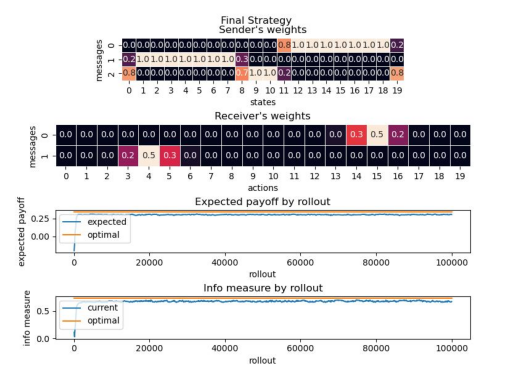

In [99]:
target_game = list(stats_ba['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
# I had to hardcode this, no brain cycles left
display_game(directory + "(1, 0.3)_null_100000_387.jpg")

### d = 0.25
reward = 1 - 0.25x

In [100]:
directory = "./simulations/20_2_20/final_results/large batch/reciever_stimgen/25/"
stats_bb = get_stats_by_folder(directory)

In [101]:
print_stats(stats_bb)

Vagueness: 22
Both Signals: 898
One Signal: 102
No Signals: 0
Reciever Agreement: 2
Non-contiguity: 0
Edges: 985
Average payoff: 0.3476920491883744


In [102]:
print(repr(stats_bb["vagueness"]))

{'null_usage_1_0.25_753.csv', 'null_usage_1_0.25_229.csv', 'null_usage_1_0.25_828.csv', 'null_usage_1_0.25_932.csv', 'null_usage_1_0.25_760.csv', 'null_usage_1_0.25_990.csv', 'null_usage_1_0.25_54.csv', 'null_usage_1_0.25_660.csv', 'null_usage_1_0.25_525.csv', 'null_usage_1_0.25_599.csv', 'null_usage_1_0.25_232.csv', 'null_usage_1_0.25_695.csv', 'null_usage_1_0.25_759.csv', 'null_usage_1_0.25_178.csv', 'null_usage_1_0.25_969.csv', 'null_usage_1_0.25_638.csv', 'null_usage_1_0.25_72.csv', 'null_usage_1_0.25_459.csv', 'null_usage_1_0.25_126.csv', 'null_usage_1_0.25_757.csv', 'null_usage_1_0.25_262.csv', 'null_usage_1_0.25_648.csv'}


### d = 0.2
reward = 1 - 0.2x

In [103]:
directory = "./simulations/20_2_20/final_results/large batch/reciever_stimgen/20/"
stats_bc = get_stats_by_folder(directory)

In [104]:
print_stats(stats_bc)

Vagueness: 6
Both Signals: 989
One Signal: 11
No Signals: 0
Reciever Agreement: 0
Non-contiguity: 1
Edges: 905
Average payoff: 0.4434456004058058


In [105]:
print(repr(stats_bc["vagueness"]))

{'null_usage_1_0.2_498.csv', 'null_usage_1_0.2_471.csv', 'null_usage_1_0.2_958.csv', 'null_usage_1_0.2_448.csv', 'null_usage_1_0.2_889.csv', 'null_usage_1_0.2_354.csv'}


null_usage_1_0.2_498.csv
0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0/null | 2 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1
(np.int64(4), np.int64(17))
Null used: True
Mixed signaling: False
Labels: Vague between 11 and 12


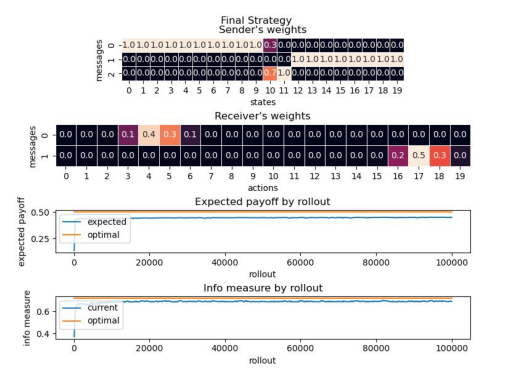

In [106]:
target_game = list(stats_bc['vagueness'])[0]
print(target_game)
game_report(directory + target_game)
# I had to hardcode this, no brain cycles left
display_game(directory + "(1, 0.2)_null_100000_498.jpg")